<a href="https://colab.research.google.com/github/haji8-de/AIFFEL_quest_rs/blob/main/GoingDeeper/Deep01/goingdeeper01_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 나를 찾아줘 - Class Activation Map 만들기 [프로젝트]

## 목표 : CAM 과 grad CAM을 구현해보자++

* 사전학습된 resnet50 을 가지고 stanford_dogs 데이터를 추가 학습하여, 더 빨리 더 높은 정확도를 가진 모델을 구한다.
* 구한 모델을 통해, 개가 나온 사진에 히트맵으로 표현하고 이를 bbox로 만들어 정답지인 box와 비교해본다
* 비교 방식은 IOU (교집합 영역/합집합 영역) 방식을 사용한다.
아래 소스는 모든 소스가 아니고, 데이터 다운로드 소스등 두번 시행할 필요가 없는 소스는 제외되었습니다.
혹시 데이터가 없는 상태에서 실행을 할 경우 cam-gradcam.ipynb 파일을 참고하여 시행하시면 됩니다.


### ResNet50 + GAP + DenseLayer 결합된 CAM 모델의 학습과정이 안정적으로 수렴하였다.

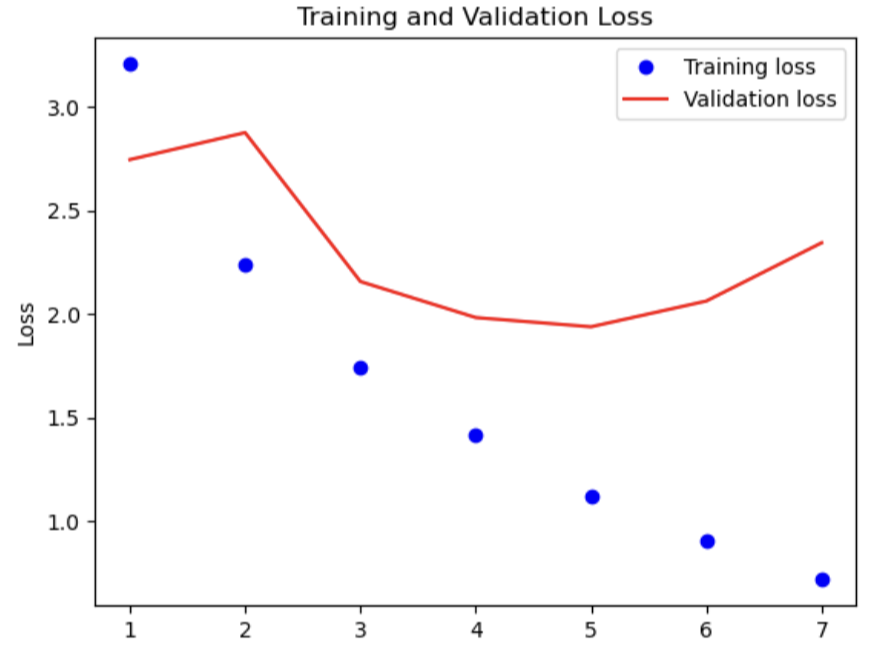

 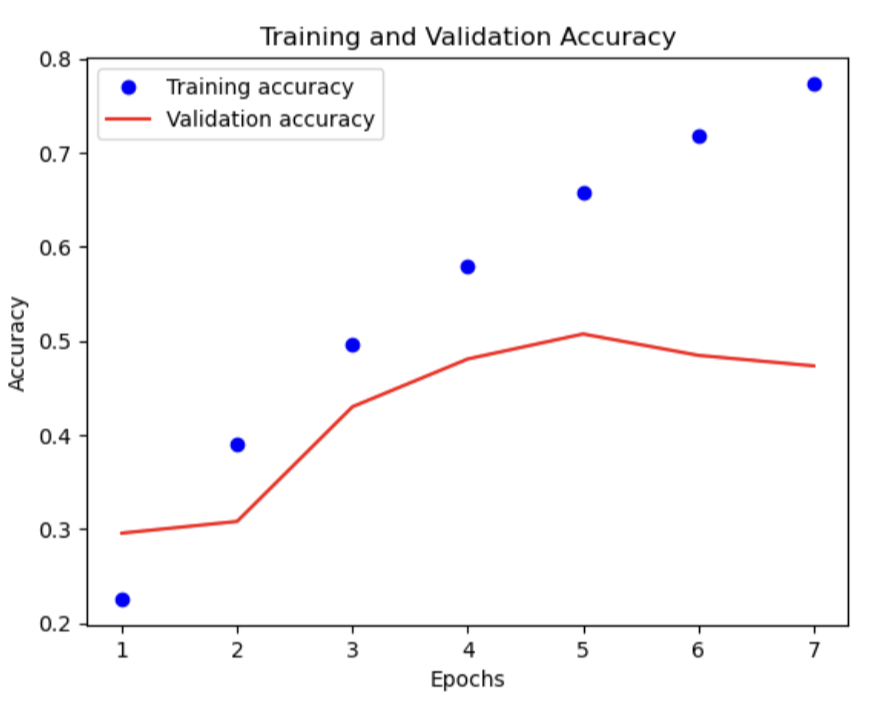

### 분류근거를 설명 가능한 Class activation map을 얻을 수 있는가?

 * CAM 방식과 Grad-CAM 방식의 class activation map이 정상적으로 얻어지며, 시각화하였을 때 해당 object의 주요 특징 위치를 잘 반영한다.
### 인식결과의 시각화 및 성능 분석을 적절히 수행하였는가?

 * CAM과 Grad-CAM 각각에 대해 원본이미지합성, 바운딩박스, IoU 계산 과정을 통해 CAM과 Grad-CAM의 object localization 성능이 비교분석되었다.

```
# 59 어두움
# 60 두마리
# 63 자동차
# 153 정상
# 158 눈 안보임
# 159 가둠

# 빨강 -> 검출된
# 초록 -> 원래 라벨링된

#1361 1387 대조군 사람이 검은옷을 입지 않음
#1364 4마리의 개가 철장에 갇힘
#1366 두마리의 강아지가 같은 사이즈
#1367 화면을 가득 채운
#1370 사람이 동일 색으로 뒤에 같이 섰을때
#1396 어두운 배경의 색상과 강아지가 비슷한 색일때
#1395 강아지 세마리가 비슷한 사이즈일댜 검출하는 것 -> 강아지를 다르게 검출했으나 iou 0
```
## 초록 박스 에러 문제로 재시도


의문점 : 왜 layer4 까지 밖에 되지 않는가?
![img03.png](attachment:818d193b-d52e-4946-8370-b5075bdb373a.png)

### 평균적으로 57%정도의 성능을 보이며,

5771의 경우 전체 영역 자체가 작은데 그중 검출된부분이 더욱 작아 0.07 값이 나왔는데, 작은 객체일 수록 iou값이 낮게 나올 수 있다는 점을 확인 할 수 있었음.
6473의 경우도 거의 비슷한데도 불구하고 iou값이 낮게 나옴

### iou 값의 오류가 확인되어 다시 작업


📝 루브릭 점검 및 현재 진행 상황
![img10.png](attachment:1aff239e-a25c-4f83-a5f1-14c495130e09.png)
![img11.png](attachment:da06e5c8-5e3b-4a9b-9451-c66cc384ef93.png)
![img12.png](attachment:dc007240-ae5c-480f-a26e-996d78fbab3b.png)
![img13.png](attachment:0b8e311d-740d-482b-a3c0-b74583091d5a.png)
![img14.png](attachment:38ff690a-78ca-454a-bce6-50498f6e3cdc.png)
![img15.png](attachment:fd65b141-b905-452e-9dab-3aa291a9f8ba.png)




6972의 경우 작은 강아지로 iou 값이 적게 나타남
2599의 경우 여러 강아지중 각기 다른 강아지를 가르쳐 iou =0을 가르킴
1411의 경우 여러 강아지를 얼굴만 다같이 검출하였는데, 라벨링은 한 마리만 라벨링
초록색 라벨링된 박스의 범위에 비해, 빨간 박스가 더욱 작게 나타남
레이어를 거치면서 3184처럼 다리 부근에 있는 히트맵이 사라지는 것을 볼 수 있고 이는 전반적으로 뚜렷하게 나타나는 특징점이다.
이떄 어떻게 하면 이 모델을 더욱 효과적으로 발전시킬 수 있을까?



# 제미나이 답변
CAM(Class Activation Map) 기반의 약지도 학습(Weakly Supervised Object Localization, WSOL)이 가지는 전형적이고 고질적인 한계점들입니다. 분류(Classification)용으로 학습된 모델에게 억지로 위치를 찾게 하다 보니 생기는 부작용들이죠.
이 모델을 더욱 효과적으로 발전시키기 위한 해결책을 분석하신 문제점들에 맞춰 4가지 방향으로 제시해 드립니다.
*  붉은 박스가 너무 작고, 다리 쪽 히트맵이 사라지는 현상 (Case 3184 등)
원인: 모델은 이 사진이 개(Dog)인가? 라는 분류 문제만 풀면 됩니다. 개를 식별하는 데 가장 강력한 힌트는 얼굴(코, 눈)입니다. 모델은 굳이 몸통이나 다리까지 보지 않아도 얼굴만 보고 정답을 맞힐 수 있으므로, 깊은 레이어(Layer 4)로 갈수록 가장 특징적인 부분(Discriminative part) 하나에만 좁게 집중(Over-reliance)하는 게으른 선택을 합니다.

* 여러 마리의 개가 있을 때의 혼란과 라벨링 불일치 (Case 2599, 1411)
원인: CAM은 이미지 전체에 개가 있다/없다 라는 이미지 레벨 라벨(Image-level label)로만 학습되었습니다. 사진에 개가 3마리 있을 때, 모델은 똑똑하게 3마리의 얼굴을 모두 찾아내 히트맵을 붉게 물들입니다(Case 1411). 하지만 정답(Ground Truth) 바운딩 박스는 그중 한 마리에게만 쳐져 있다면 당연히 IoU는 박살이 납니다. 반대로 모델이 우측 개를 가리켰는데 정답은 좌측 개일 수도 있죠(Case 2599)

*  작은 객체에서의 낮은 IoU (Case 6972)
CNN(ResNet 등)을 통과하며 레이어가 깊어질수록 Feature Map의 해상도는 가로세로 1/32 수준으로 쪼그라듭니다. (예: 224X224 이미지가 7X7이 됨). 원래도 작은 강아지가 7X7 크기의 맵에서는 불과 1~2 픽셀로 뭉개져 버리기 때문에 정확한 박스를 치기 어렵습니다.


* 후처리(Post-processing) 알고리즘 고도화
현재는 히트맵에서 임계값(threshold=0.3 등)을 기준으로 싹둑 잘라내어 박스를 치고 있습니다. 이는 개의 털 색깔이나 배경과의 대비에 따라 박스가 너무 작게 또는 너무 크게 쳐지는 원인이 됩니다.


    결론적으로 현재 단계에서 가장 극적인 개선을 이끌어내고 싶으시다면,
```
바운딩 박스를 추출하는 get_bbox 함수의 threshold 값을 조금 낮춰서 박스 크기를 키워보고,
가능하시다면 레이어 3과 레이어 4의 Grad-CAM 결과를 반반씩 더해서 (Fusion) 새로운 히트맵을 만들어 보세요.
다리 부근의 히트맵이 살아나면서 IoU가 확 오르는 것을 관찰하실 수 있을 겁니다!
```

### threshold ==0.3 -> threshold = 0.1
바운딩 박스 추출 로직 변경

![img20.png](attachment:10637b1a-ad13-4ef3-9d84-abe6b9efbd27.png)
![img22.png](attachment:3cf542a4-49f4-40e8-ad38-3be58c34ff00.png)
![img23.png](attachment:b08cfbea-3283-493c-b0ca-76ebe9898b8c.png)



### 변경후

변경만으로 전체적으로 10~25%정도 iou가 오름을 확인할 수 있었음4421은 0.89의 상승을 보임

# 회고

중간 중간 회의시간이 있어서 회의하면서 어떤 내용이 진행되고 있는지 공유하기 좋았고
공유를 통해 내 코드를 다시 보면서 소스에 문제점을 깨달아서 좋았습니다.

바운딩 박스 문제랑 iou문제를 후반부에 깨달아서 고치느라 고생했네요 ㅠㅠ

제미나이에게 정리된내용을 물어봐서 개선점을 얻고, 그중 실행 가능한 부분만
실행하여 상향된 효과를 볼 수 있어서 좋았습니다.

In [ ]:
!pip install opencv-python
!pip install torchinfo

In [ ]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F
from torchinfo import summary

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [ ]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8600


In [ ]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

label: 0, i : 0
Label index: 0
Class name: n02085620-Chihuahua


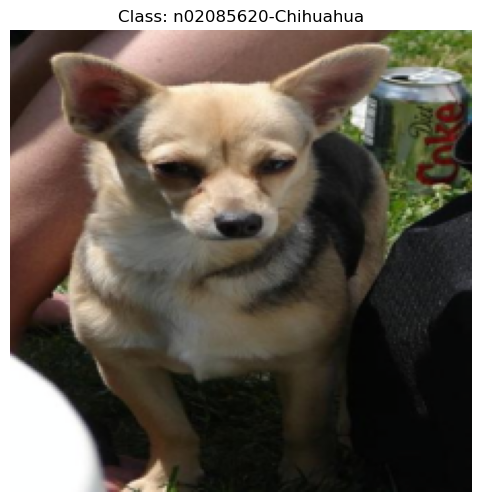

0
0
label: 0, i : 1
Label index: 0
Class name: n02085620-Chihuahua


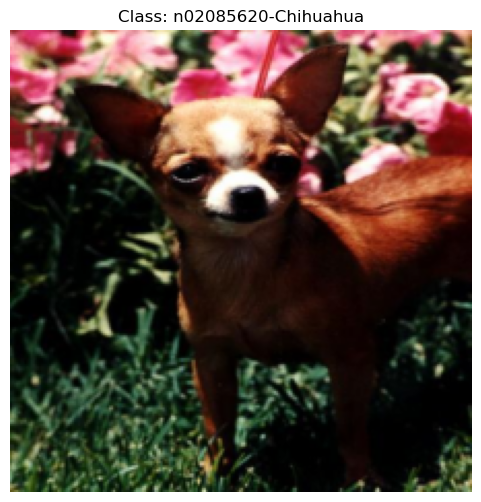

1
label: 0, i : 2
Label index: 0
Class name: n02085620-Chihuahua


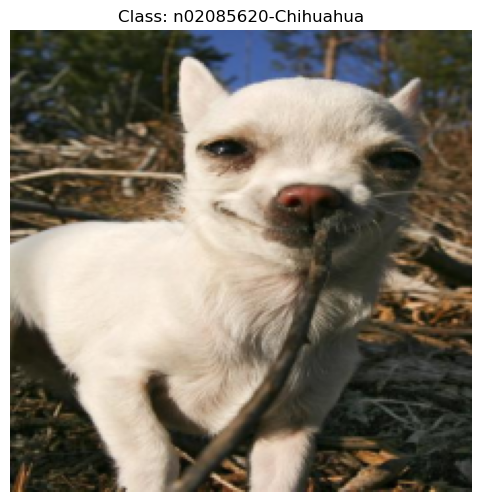

2


In [ ]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
# valid_sample = valid_dataset[0]

# visualize(valid_sample)

for i in range(3): #50,len(valid_dataset)):
    #if i == 105:
    img_tensor, label, bbox = valid_dataset[i]
# if (valid_dataset.classes[label] =="n02089973-English_foxhound"):
    print("label: " + str(label) + ", i : " + str(i))
    visualize(valid_dataset[i])
    print(i)
    if i %1000 == 0 :
        print(i)

In [ ]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation/n02085782-Japanese_spaniel/n02085782_2695')

#work/haji/workplace/AIFFEL_quest_rs/GoingDeeper/Deep01/stanford_dogs/test/n02085782-Japanese_spaniel/n02085782_2695.jpg
# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085782
filename: n02085782_2695
source: 
		
database: ImageNet database
size: 
		
width: 399
height: 255
depth: 3
segment: 0
object: 
		
name: Japanese_spaniel
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 153
ymin: 52
xmax: 303
ymax: 215
object: 
		
name: Japanese_spaniel
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 39
ymin: 33
xmax: 158
ymax: 187


In [ ]:
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model = model.to(device)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
summary(model)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Conv2d: 1-1                            9,408
├─BatchNorm2d: 1-2                       128
├─ReLU: 1-3                              --
├─MaxPool2d: 1-4                         --
├─Sequential: 1-5                        --
│    └─Bottleneck: 2-1                   --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─Bottleneck: 2-2                   --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12            128
│    │    └─Conv2d: 3-13               

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy

def train_val_accs_visualization(train_accs, val_accs, epochs=20):
    epochs_range = range(1, epochs + 1)

    if len(train_accs) < epochs:
        for i in range(epochs - len(train_accs)):
            train_accs.append(train_accs[-1])

    if len(val_accs) < epochs:
        for i in range(epochs - len(val_accs)):
            val_accs.append(val_accs[-1])

    plt.clf()

    plt.plot(epochs_range, train_accs, 'bo', label='Training accuracy')
    plt.plot(epochs_range, val_accs, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def train_val_loss_visualization(train_losses, val_losses, epochs=20):
    epochs_range = range(1, epochs + 1)

    if len(train_losses) < epochs:
        for i in range(epochs - len(train_losses)):
            train_losses.append(train_losses[-1])

    if len(val_losses) < epochs:
        for i in range(epochs - len(val_losses)):
            val_losses.append(val_losses[-1])

    plt.plot(epochs_range, train_losses, 'bo', label='Training loss')
    plt.plot(epochs_range, val_losses, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        val_losses.append(test_loss)
        val_accs.append(test_acc)
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")
    train_val_loss_visualization(train_losses, val_losses, epochs=num_epochs)
    train_val_accs_visualization(train_accs, val_accs, epochs=num_epochs)
    return model


Epoch 1/2 시작
  Step 50 - Loss: 5.3767
  Step 100 - Loss: 3.6273
  Step 150 - Loss: 4.9856
  Step 200 - Loss: 4.7116
  Step 250 - Loss: 4.5355
  Step 300 - Loss: 3.4890
  Step 350 - Loss: 3.3628
  Step 400 - Loss: 2.7930
  Step 450 - Loss: 2.5253
  Step 500 - Loss: 2.8029
  Step 550 - Loss: 3.1419
  Step 600 - Loss: 2.7184
  Step 650 - Loss: 2.9603
  Step 700 - Loss: 4.0386
  Step 750 - Loss: 2.8593
  Step 800 - Loss: 2.8598
  Step 850 - Loss: 2.8528
  Step 900 - Loss: 3.2006
  Step 950 - Loss: 2.2220
  Step 1000 - Loss: 2.8795
Train - Loss: 3.2056, Accuracy: 22.26%
Annotation file not found: /home/jovyan/work/class_activation_map/Annotation/n02085782-Japanese_spaniel/.ipynb_checkpoints/n02085782_17-checkpoint
Annotation file not found: /home/jovyan/work/class_activation_map/Annotation/n02085782-Japanese_spaniel/.ipynb_checkpoints/n02085782_1836-checkpoint
Annotation file not found: /home/jovyan/work/class_activation_map/Annotation/n02085782-Japanese_spaniel/.ipynb_checkpoints/n0208578

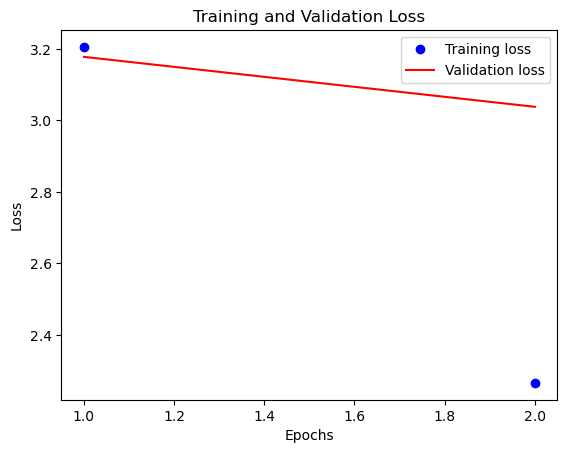

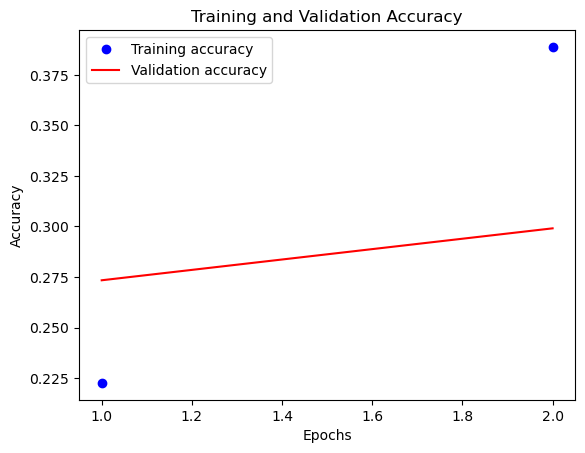

CPU times: user 4min 59s, sys: 10.7 s, total: 5min 10s
Wall time: 5min 15s


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2)

In [ ]:
# Q. '/work/class_activation_map' 에 'cam_model1.h5'을 저장하세요.

cam_model_path = os.path.join(os.getenv("HOME"), "work/class_activation_map/cam_model_haji.pt")

torch.save(model, cam_model_path)

In [ ]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [ ]:
cam_model_path = os.path.join(os.getenv("HOME"), "work/class_activation_map/cam_model_haji.pt")

In [ ]:
# 모델을 불러오세요

# [[YOUR CODE]]
model = torch.load(cam_model_path, weights_only=False)

In [ ]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [ ]:
cam = generate_cam(model, sample_image)

In [ ]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

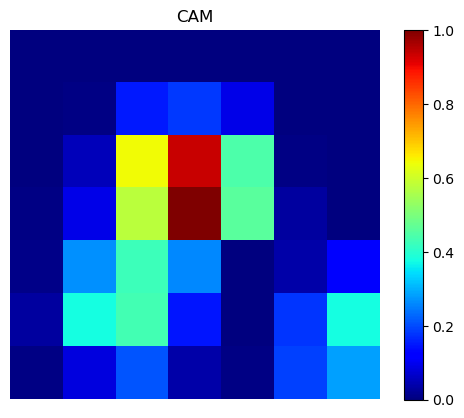

In [ ]:
visualize_cam(cam)

In [ ]:
def visualize_cam_on_image_2(cam, img, alpha=0.5):

    blended_img = cv2.addWeighted(cam, alpha, img, 1 - alpha, 0)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

In [ ]:
# visualize_cam_on_image_2(cam_image, sample_image,0.3)

In [ ]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

#    blended_img = cv2.addWeighted(cam, alpha, img, 1 - alpha, 0)


    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

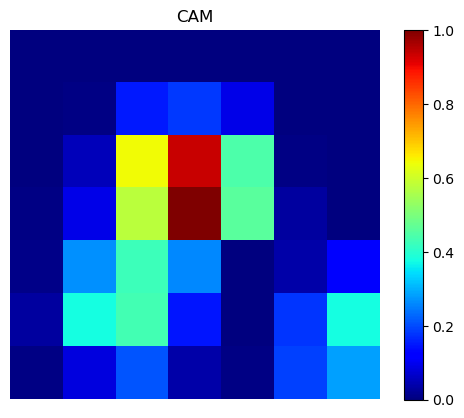

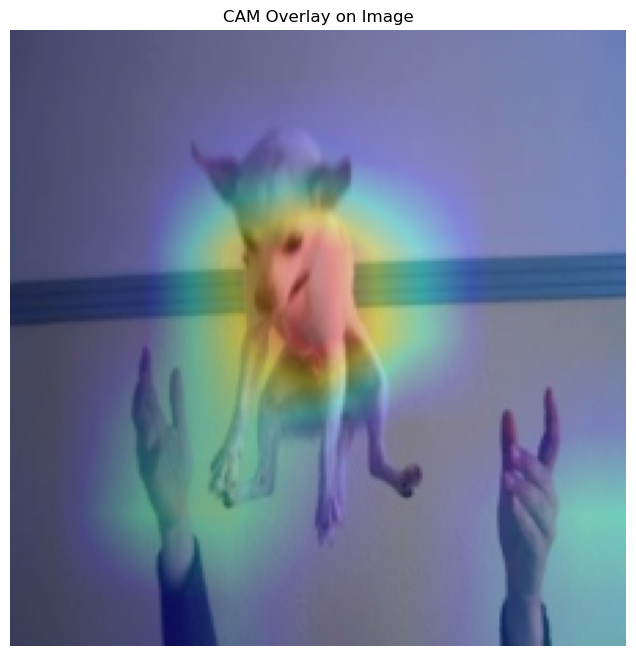

In [ ]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img,0.3)

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


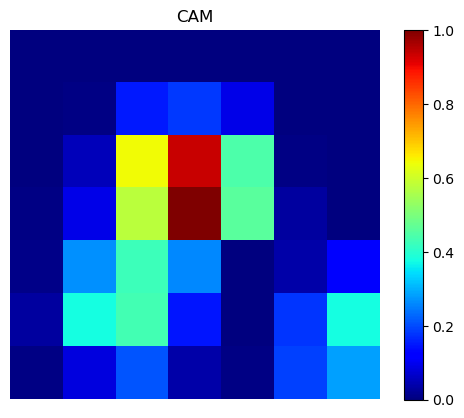

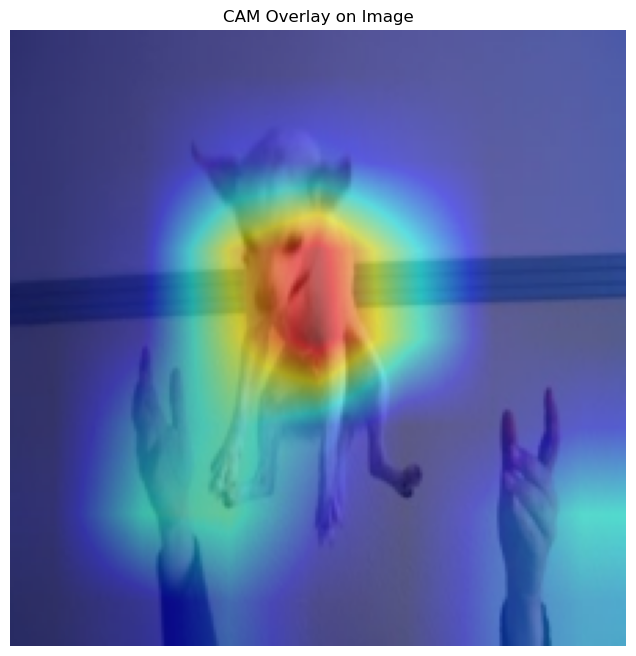

In [ ]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

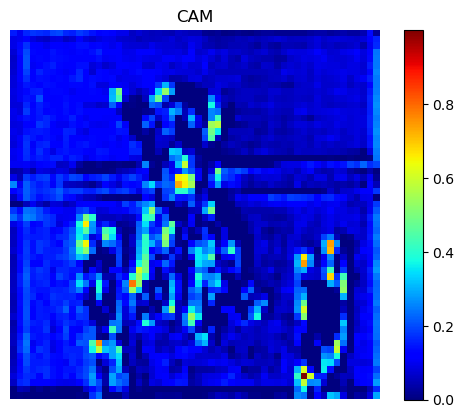

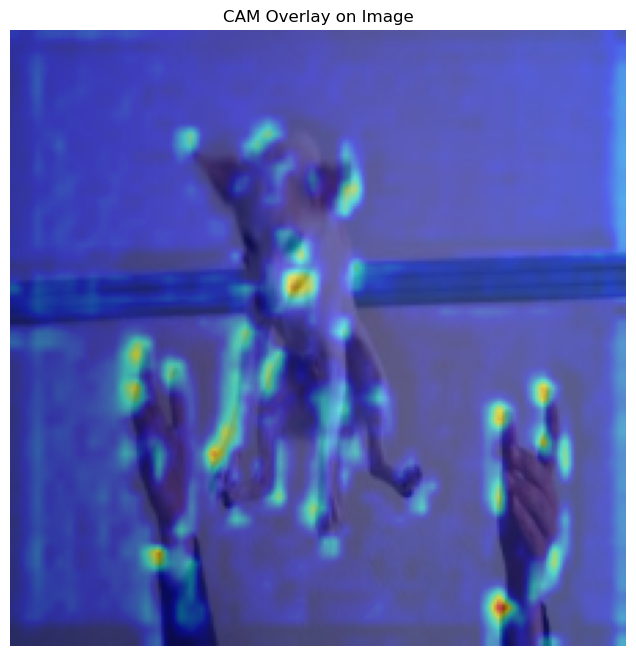

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

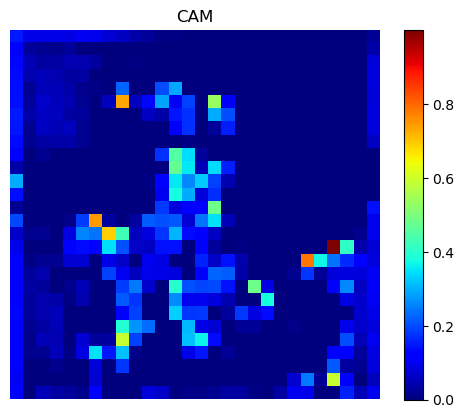

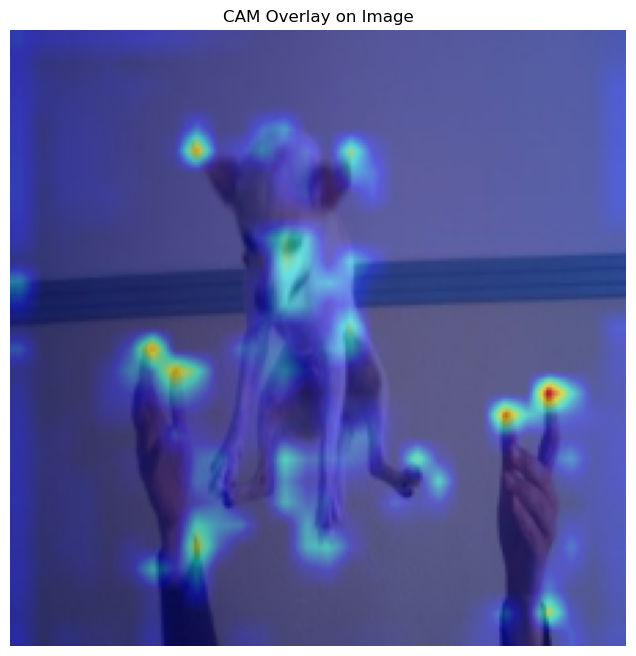

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer2")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

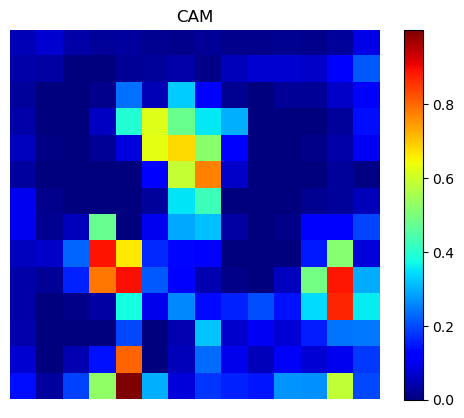

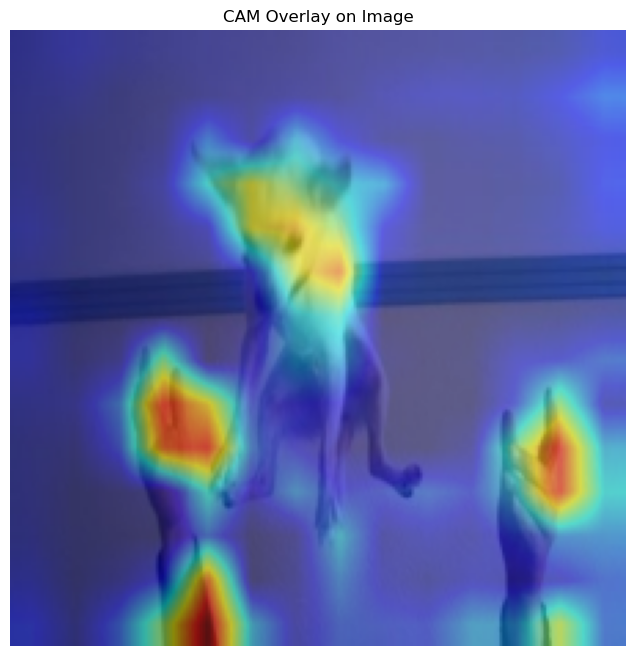

In [ ]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

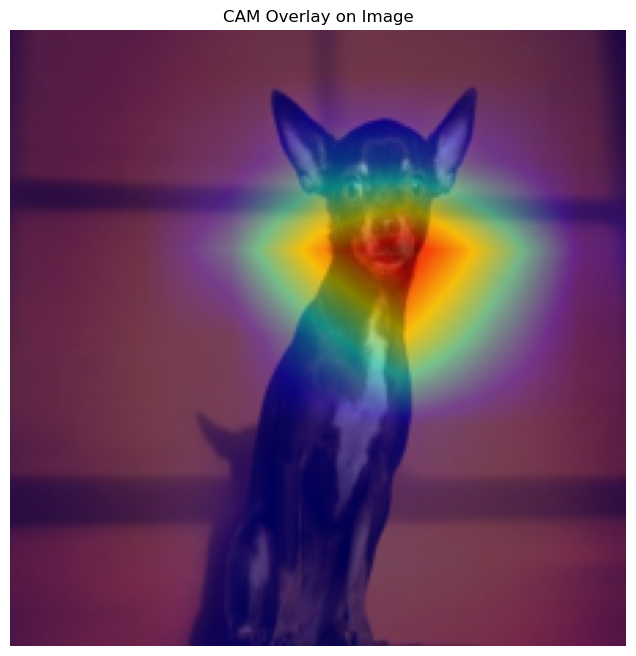

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [ ]:
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.5)

print(bbox)

(np.int64(72), np.int64(62), np.int64(141), np.int64(133))


In [ ]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

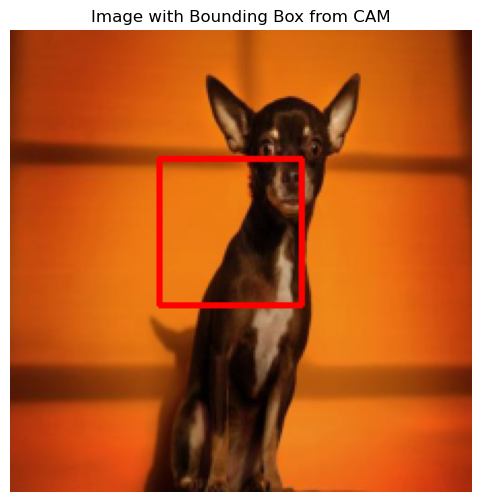

In [ ]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

In [ ]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

In [ ]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [ ]:
get_iou(bbox, ground_bbox)

np.float64(0.23326475964720972)

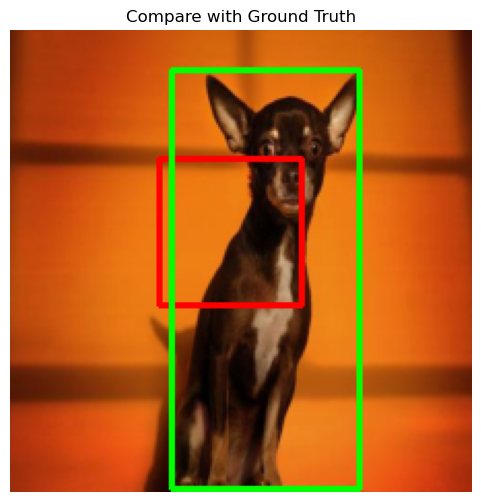

In [ ]:
def visualize_both_bbox_on_image(img, bbox, ground_bbox, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

In [ ]:
def get_iou(gt_bbox, pred_bbox):
    # 두 박스 중 하나라도 없으면 IOU는 0
    if gt_bbox is None or pred_bbox is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = gt_bbox
    x_min2, y_min2, x_max2, y_max2 = pred_bbox

    # 교집합 영역 계산 (겹치는 부분의 좌표)
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합 너비/높이 → 음수가 나오면 0으로 처리
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 박스의 면적
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 = 각 영역 합 - 교집합
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    # 최종 IoU 계산
    iou = inter_area / union_area
    return iou

In [ ]:
get_iou(ground_bbox, bbox)

np.float64(0.23326475964720972)

In [ ]:
random_num = np.random.randint(0, len(valid_dataset))
print(random_num)
image, label, bbox = valid_dataset[random_num]
sample_valid_image = image.unsqueeze(0).to(device)

2812


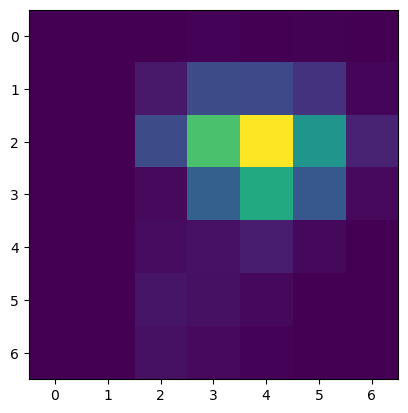

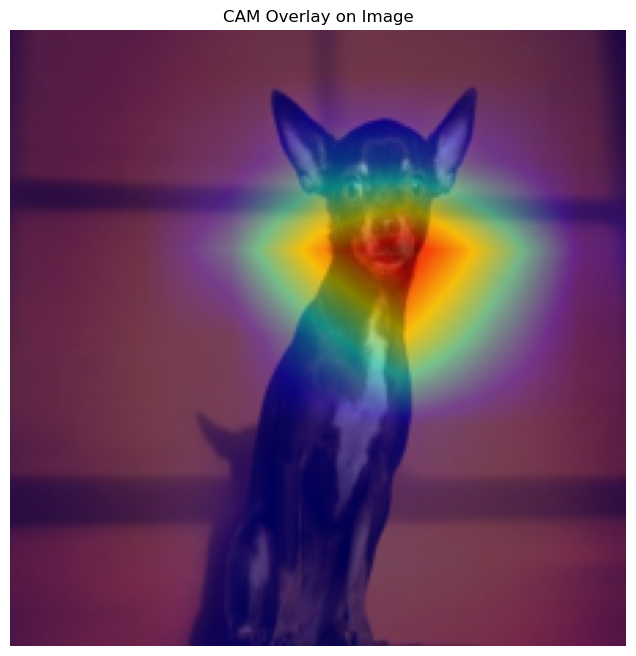

In [ ]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")
plt.imshow(grad_cam)
visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

In [ ]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [ ]:
def visualize_both_bbox_on_image_c(img, bbox, ground_truth, thickness=2):
    # OpenCV 함수 오류를 방지하기 위해 배열이 메모리에 연속적으로 배치되도록 보장
    img_with_bbox = np.ascontiguousarray(img.copy())

    # [디버깅용 출력] 터미널에 좌표를 직접 찍어서 확인해 봅니다.
    # 만약 bbox가 (0,0,0,0)으로 나온다면 get_bbox의 threshold 값을 낮춰야 합니다.
    # print(f"Pred: {bbox}, GT: {ground_truth}")

    # 1. 정답(ground_truth) 박스를 먼저 '두껍게' 그리기 (초록색)
    x_min_t, y_min_t, x_max_t, y_max_t = map(int, ground_truth)
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness + 2)

    # 2. 예측(bbox) 박스를 그 위에 '얇게' 그리기 (빨간색)
    # (주의: 이미지에 따라 RGB가 (255,0,0)이 빨강일수도, 파랑일수도 있습니다.)
    x_min, y_min, x_max, y_max = map(int, bbox)
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    return img_with_bbox

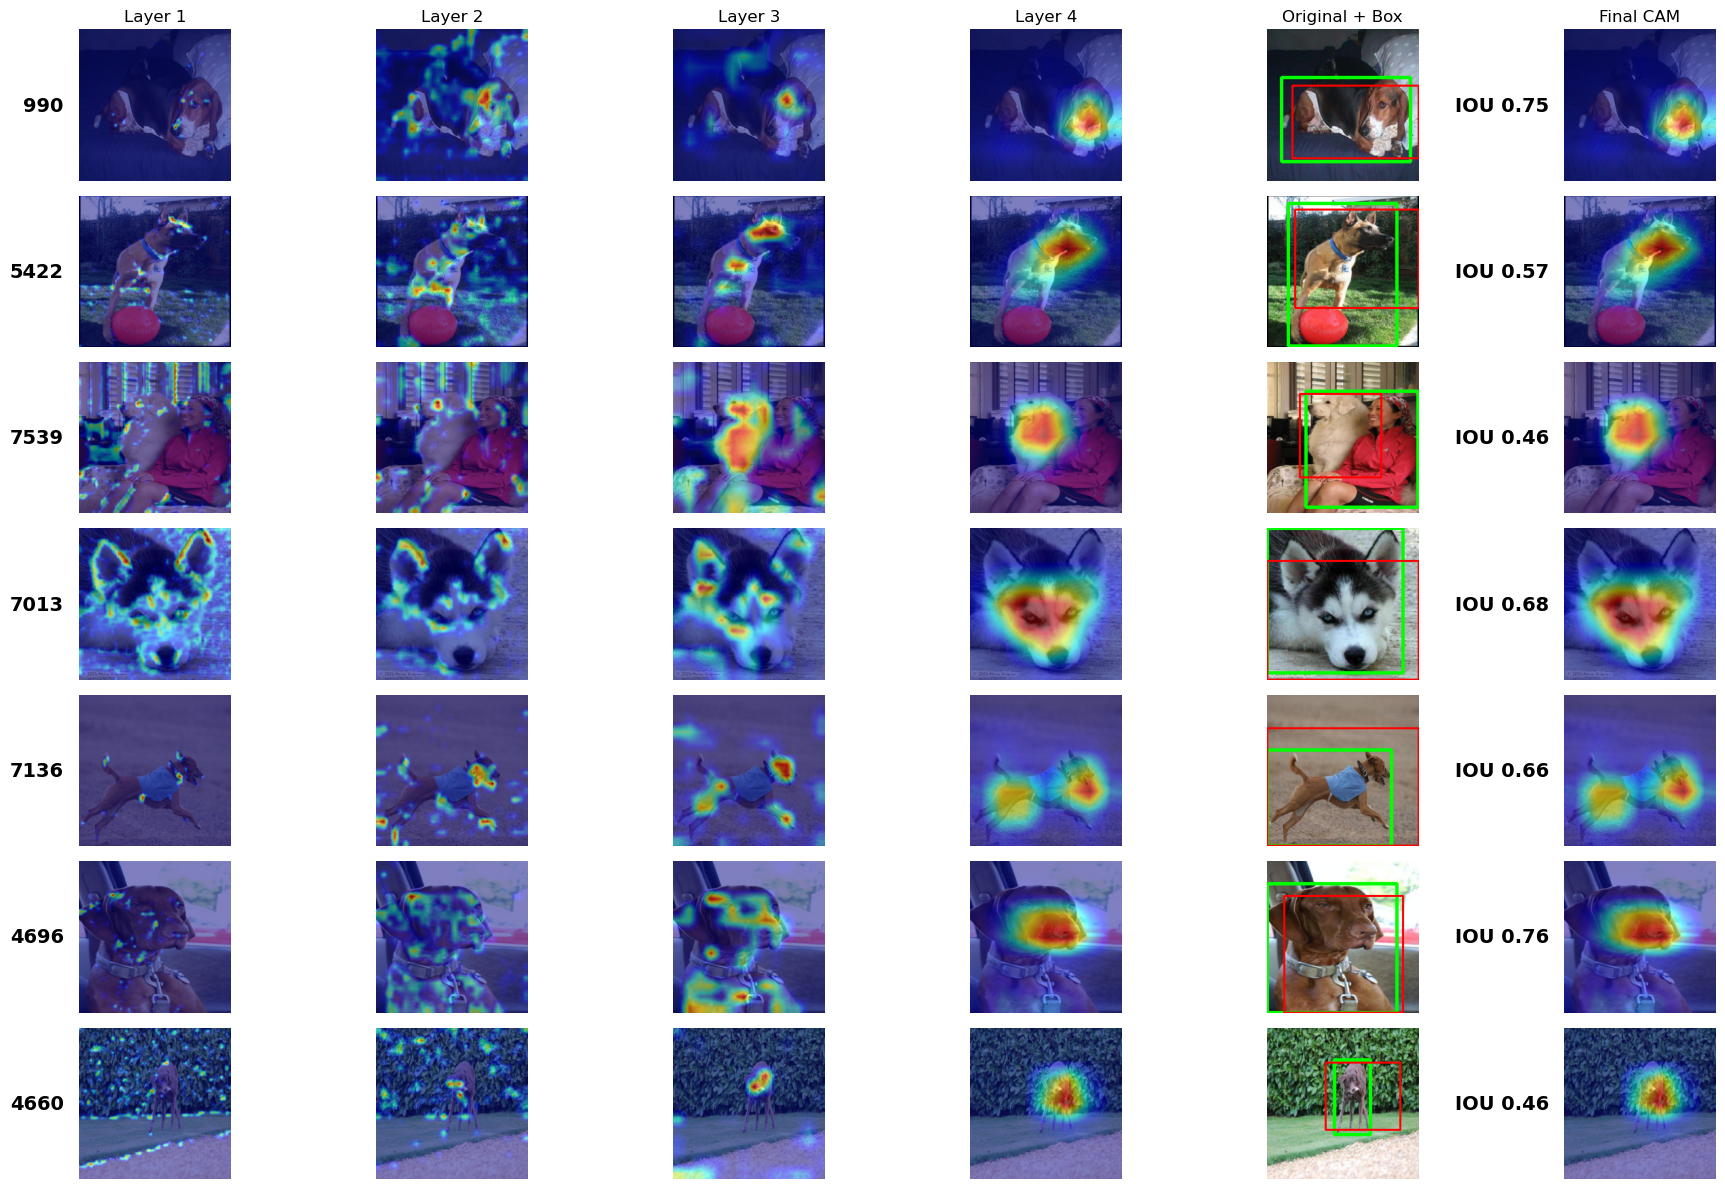

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 5행 6열 서브플롯 생성
# figsize는 인치 단위 (가로, 세로) - 화면에 맞게 조절하세요
fig, axes = plt.subplots(nrows=7, ncols=6, figsize=(18, 12))

import matplotlib.pyplot as plt
import numpy as np

alpha= 0.5
for r in range(7):

    # if r == 0:
    #     random_num = 1361
    # elif r ==1:
    #     random_num = 1364
    # elif r ==2:
    #     random_num = 1366
    # elif r ==3:
    #     random_num = 1367
    # elif r ==4:
    #     random_num = 1370
    # elif r ==5:
    #     random_num = 1386
    # elif r ==6:
    #     random_num = 1395
    # # pred_bbox_c =

    # 1. 랜덤 이미지 로드
    random_num = np.random.randint(0, len(valid_dataset))
    image_0, label_0, bbox_0 = valid_dataset[0]
    image_0 = image_0.to(device)
    image_0 = image_0.unsqueeze(0).to(device)
    # [C, H, W] -> [1, C, H, W]
    cam_c = generate_cam(model, image_0)
    # print(random_num)
    for c in range(6):
        # random_num = random_num+1
        image_c, label_c, bbox_c = valid_dataset[random_num]

        cam_resized_c = cv2.resize(cam, (image_c.shape[1], image_c.shape[0]))
        pred_bbox_c = get_bbox(cam_resized_c, threshold=0.1)

        # 1. 모델 입력용 4차원 텐서 준비
        image_tensor = image_c.unsqueeze(0).to(device)

        # ---------------------------------------------------------
        # 2. [공통] 원본 이미지를 0~255 컬러 이미지(uint8)로 복원
        # ---------------------------------------------------------
        valid_image = image_c.cpu().squeeze().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])

        valid_image_unnorm = std * valid_image + mean
        valid_image_unnorm = np.clip(valid_image_unnorm, 0, 1)
        valid_image_uint8 = (valid_image_unnorm * 255).astype(np.uint8)

        # ---------------------------------------------------------
        # 3. 열(c)에 따라 다르게 처리 (c=4는 원본+박스 / 나머지는 CAM)
        # ---------------------------------------------------------
        if c == 4:
            # [4번째 열] 원본 이미지 그대로 복사 후 바운딩 박스 그리기
            overlay = valid_image_uint8.copy()
            # 방금 만든 최종 CAM에서 예측 박스 추출!
            pred_bbox = get_bbox(cam_resized, threshold=0.1)

            # 합성된 이미지 위에 예측 박스(빨강)와 정답 박스(초록) 모두 그리기
            overlay = visualize_both_bbox_on_image_c(overlay, pred_bbox, bbox_c)

        else:
            # [나머지 열] CAM 생성
            if c < 4:  # 0, 1, 2, 3 열 -> 각 Layer별 Grad-CAM
                layer_name = "layer" + str(c+1)
                cam_c = generate_grad_cam(model, image_tensor, target_layer_name=layer_name)
            elif c == 5: # 5 열 -> 최종 CAM
                cam_c = generate_cam(model, image_tensor)

            # CAM 리사이즈 및 히트맵 컬러 변환
            cam_resized = cv2.resize(cam_c, (valid_image_uint8.shape[1], valid_image_uint8.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

            # 원본 이미지와 히트맵 합성 (Alpha Blending)
            overlay = heatmap * alpha + valid_image_uint8 * (1 - alpha)
            overlay = overlay.astype(np.uint8)

            # (선택) CAM 위에도 박스를 그리고 싶다면 아래 주석을 해제하세요!
            # overlay = visualize_both_bbox_on_image_c(overlay, bbox_c, ground_bbox)

        # ---------------------------------------------------------
        # 4. 결과 출력 및 타이틀/축 설정
        # ---------------------------------------------------------
        axes[r, c].imshow(overlay)
        axes[r, c].axis('off')

        # 첫 번째 행에 열(Column) 이름 표시
        if r == 0:
            titles = ["Layer 1", "Layer 2", "Layer 3", "Layer 4", "Original + Box", "Final CAM"]
            axes[r, c].set_title(titles[c])

    axes[r, 0].text(-0.1, 0.5, f"{random_num}",
                    transform=axes[r, 0].transAxes,
                    fontsize=14, fontweight='bold',
                    va='center', ha='right')
    # 행 타이틀 추가 (for c 루프 바깥에 위치해야 정상 작동함)
    axes[r, 5].text(-0.1, 0.5, f"IOU {get_iou(pred_bbox, bbox_c):.2f}",
                    transform=axes[r, 5].transAxes,
                    fontsize=14, fontweight='bold',
                    va='center', ha='right')

# 서브플롯 간 간격 자동 조절
plt.tight_layout()

# 그래프 표시
plt.show()


# 59 어두움
# 60 두마리
# 63 자동차
# 153 정상
# 158 눈 안보임
# 159 가둠

# 빨강 -> 원래 라벨링된
# 초록 -> 검출된

#1361 1387 대조군 사람이 검은옷을 입지 않음
#1364 4마리의 개가 철장에 갇힘
#1366 두마리의 강아지가 같은 사이즈
#1367 화면을 가득 채운
#1370 사람이 동일 색으로 뒤에 같이 섰을때
#1396 어두운 배경의 색상과 강아지가 비슷한 색일때
#1395 강아지 세마리가 비슷한 사이즈일댜 검출하는 것 -> 강아지를 다르게 검출했으나 iou 0
